<a href="https://colab.research.google.com/github/Jdsolliday/foh-cleaning-tracker/blob/main/rocket_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# ============================================================
# CELL 1 — ROCKET CONFIGURATION (2D: launch angle + wind!)
# ============================================================

import numpy as np

# Mass
DRY_MASS        = 0.5
PROPELLANT_MASS = 0.1
TOTAL_MASS      = DRY_MASS + PROPELLANT_MASS

# Aerodynamics (rocket body)
DIAMETER        = 0.04
CD              = 0.5

# Thrust curve
THRUST_CURVE = [
    (0.000,  0.0),
    (0.050, 12.0),
    (0.100, 18.0),
    (0.200, 20.0),
    (0.500, 19.0),
    (1.000, 17.0),
    (1.500, 15.0),
    (1.800, 10.0),
    (1.900,  5.0),
    (2.000,  0.0),
]

BURN_TIME = THRUST_CURVE[-1][0]

# Parachute
CHUTE_DIAMETER  = 0.3
CHUTE_CD        = 1.5
CHUTE_AREA      = np.pi * (CHUTE_DIAMETER / 2) ** 2

# ── 2D PARAMETERS (new!) ──
LAUNCH_ANGLE    = 85.0      # degrees from horizontal (90 = straight up, 85 = slight tilt)
WIND_SPEED      = 2.0       # m/s horizontal wind (positive = pushes in +x direction)

print("✅ Rocket configuration loaded!")
print(f"   Total mass    : {TOTAL_MASS} kg")
print(f"   Launch angle  : {LAUNCH_ANGLE}°")
print(f"   Wind speed    : {WIND_SPEED} m/s")
print(f"   Chute diameter: {CHUTE_DIAMETER*100} cm")

✅ Rocket configuration loaded!
   Total mass    : 0.6 kg
   Launch angle  : 85.0°
   Wind speed    : 2.0 m/s
   Chute diameter: 30.0 cm


In [38]:
# ============================================================
# CELL 2 — ATMOSPHERE & PHYSICS (2D version)
# ============================================================

G = 9.81

def get_air_density(altitude):
    rho0         = 1.225
    scale_height = 8500.0
    return rho0 * np.exp(-altitude / scale_height)

def get_thrust(t):
    if t >= BURN_TIME:
        return 0.0
    for i in range(len(THRUST_CURVE) - 1):
        t0, f0 = THRUST_CURVE[i]
        t1, f1 = THRUST_CURVE[i + 1]
        if t0 <= t <= t1:
            fraction = (t - t0) / (t1 - t0)
            return f0 + fraction * (f1 - f0)
    return 0.0

def get_mass(t):
    if t < BURN_TIME:
        burn_fraction = t / BURN_TIME
        burned = burn_fraction * PROPELLANT_MASS
        return TOTAL_MASS - burned
    else:
        return DRY_MASS

def calc_drag_2d(vx, vy, altitude, chute_deployed):
    """
    2D drag — acts opposite to the direction of travel.
    First find the total speed and direction,
    then split drag force into x and y components.
    """
    rho   = get_air_density(altitude)
    speed = np.sqrt(vx**2 + vy**2)   # total speed

    if speed == 0:
        return 0.0, 0.0

    if chute_deployed:
        area = CHUTE_AREA
        cd   = CHUTE_CD
    else:
        area = np.pi * (DIAMETER / 2) ** 2
        cd   = CD

    drag_magnitude = 0.5 * rho * speed**2 * cd * area

    # Split drag into components (opposes velocity direction)
    drag_x = -drag_magnitude * (vx / speed)
    drag_y = -drag_magnitude * (vy / speed)

    return drag_x, drag_y

def calc_acceleration_2d(t, vx, vy, altitude, chute_deployed):
    """
    2D acceleration — splits thrust, drag, gravity and wind
    into x and y components.
    """
    thrust = get_thrust(t)
    mass   = get_mass(t)

    # Launch angle splits thrust into x and y
    angle_rad = np.radians(LAUNCH_ANGLE)
    thrust_x  = thrust * np.cos(angle_rad)   # horizontal component
    thrust_y  = thrust * np.sin(angle_rad)   # vertical component

    # Gravity only acts downward
    weight_y  = mass * G

    # Wind only acts horizontally (after burnout)
    wind_force_x = 0.0
    if t >= BURN_TIME:
        wind_force_x = mass * 0.1 * WIND_SPEED  # gentle wind push

    # Drag acts opposite to direction of travel
    drag_x, drag_y = calc_drag_2d(vx, vy, altitude, chute_deployed)

    # Net force in each direction
    fx = thrust_x + drag_x + wind_force_x
    fy = thrust_y - weight_y + drag_y

    return fx / mass, fy / mass

def calc_dynamic_pressure(vx, vy, altitude):
    rho   = get_air_density(altitude)
    speed = np.sqrt(vx**2 + vy**2)
    return 0.5 * rho * speed**2

print("✅ 2D Physics functions loaded!")

✅ 2D Physics functions loaded!


In [39]:
# ============================================================
# CELL 3 — SIMULATION LOOP (2D version)
# ============================================================

DT       = 0.01
MAX_TIME = 60.0

def run_simulation():
    t  = 0.0
    x  = 0.0    # horizontal position
    y  = 0.0    # vertical position (altitude)

    # Split initial velocity into components using launch angle
    angle_rad = np.radians(LAUNCH_ANGLE)
    vx = 0.0    # horizontal velocity
    vy = 0.0    # vertical velocity

    time_list     = []
    x_list        = []
    alt_list      = []
    vx_list       = []
    vy_list       = []
    speed_list    = []
    accel_list    = []
    dynpress_list = []
    chute_list    = []

    burnout_reported = False
    apogee_reported  = False
    chute_deployed   = False
    prev_vy          = 0.0

    print("Running 2D simulation...\n")

    while t <= MAX_TIME:

        if y < 0 and t > 0.5:
            print(f"  Landed   at t = {t:.2f} s  |  downrange = {x:.1f} m")
            break

        # Deploy chute at apogee
        if not chute_deployed and prev_vy > 0 and vy <= 0 and t > 0.5:
            chute_deployed = True

        ax, ay = calc_acceleration_2d(t, vx, vy, y, chute_deployed)
        q      = calc_dynamic_pressure(vx, vy, y)
        speed  = np.sqrt(vx**2 + vy**2)
        a_mag  = np.sqrt(ax**2 + ay**2)

        time_list.append(t)
        x_list.append(x)
        alt_list.append(y)
        vx_list.append(vx)
        vy_list.append(vy)
        speed_list.append(speed)
        accel_list.append(a_mag)
        dynpress_list.append(q)
        chute_list.append(chute_deployed)

        if not burnout_reported and t >= BURN_TIME:
            print(f"  Burnout  at t = {t:.2f} s  |  alt = {y:.1f} m  |  speed = {speed:.1f} m/s")
            burnout_reported = True

        if not apogee_reported and prev_vy > 0 and vy <= 0 and t > 0.5:
            print(f"  Apogee   at t = {t:.2f} s  |  alt = {y:.1f} m  ← chute deploys here!")
            apogee_reported = True

        prev_vy = vy
        vx = vx + ax * DT
        vy = vy + ay * DT
        x  = x  + vx * DT
        y  = y  + vy * DT
        t  = t  + DT

    print(f"\n  Max altitude  : {max(alt_list):.1f} m")
    print(f"  Max speed     : {max(speed_list):.1f} m/s")
    print(f"  Downrange dist: {max(x_list):.1f} m")
    landing_speed = speed_list[-1]
    print(f"  Landing speed : {landing_speed:.1f} m/s")
    max_q      = max(dynpress_list)
    max_q_time = time_list[dynpress_list.index(max_q)]
    print(f"  Max Q         : {max_q:.2f} Pa  at t = {max_q_time:.2f} s")

    return time_list, x_list, alt_list, speed_list, accel_list, dynpress_list, chute_list

print("✅ 2D Simulation loop loaded!")

✅ 2D Simulation loop loaded!


   ROCKET FLIGHT SIMULATOR - 2D



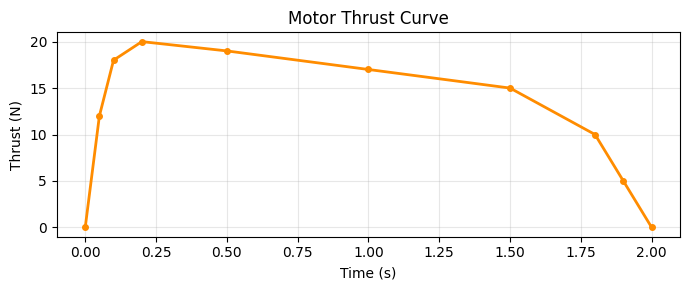

Running 2D simulation...

  Burnout  at t = 2.00 s  |  alt = 39.7 m  |  speed = 34.8 m/s
  Apogee   at t = 5.42 s  |  alt = 97.5 m  ← chute deploys here!
  Landed   at t = 17.27 s  |  downrange = 29.9 m

  Max altitude  : 97.5 m
  Max speed     : 35.3 m/s
  Downrange dist: 29.9 m
  Landing speed : 8.7 m/s
  Max Q         : 761.99 Pa  at t = 1.90 s


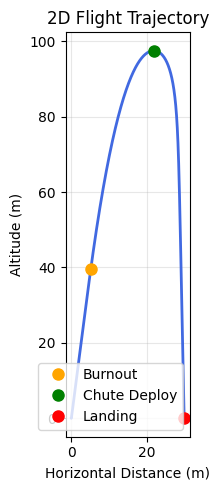

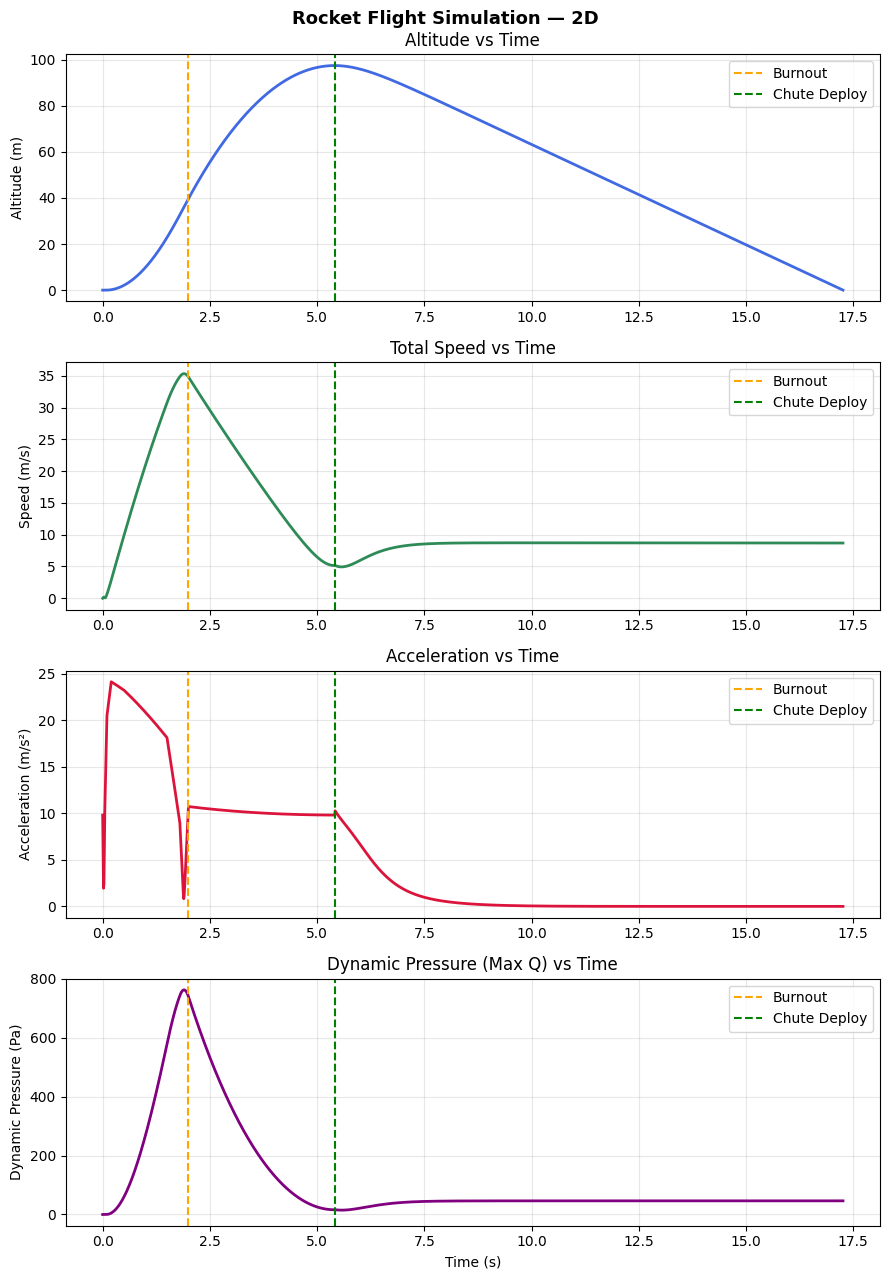

In [40]:
# ============================================================
# CELL 4 — PLOTS & RUN (2D version with trajectory plot!)
# ============================================================

import matplotlib.pyplot as plt

def plot_thrust_curve():
    times   = [p[0] for p in THRUST_CURVE]
    thrusts = [p[1] for p in THRUST_CURVE]
    plt.figure(figsize=(7, 3))
    plt.plot(times, thrusts, color='darkorange', linewidth=2, marker='o', markersize=4)
    plt.title("Motor Thrust Curve")
    plt.xlabel("Time (s)")
    plt.ylabel("Thrust (N)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_flight(time_list, x_list, alt_list, speed_list, accel_list, dynpress_list, chute_list):

    # Find key event times
    chute_time = None
    for i, deployed in enumerate(chute_list):
        if deployed:
            chute_time = time_list[i]
            break

    # ── Plot 1: 2D Trajectory (the cool new one!) ──
    fig1, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_list, alt_list, color='royalblue', linewidth=2)

    # Mark key events on trajectory
    burnout_idx = next(i for i, t in enumerate(time_list) if t >= BURN_TIME)
    ax.plot(x_list[burnout_idx], alt_list[burnout_idx], 'o',
            color='orange', markersize=8, label='Burnout')

    if chute_time:
        chute_idx = next(i for i, t in enumerate(time_list) if t >= chute_time)
        ax.plot(x_list[chute_idx], alt_list[chute_idx], 'o',
                color='green', markersize=8, label='Chute Deploy')

    ax.plot(x_list[-1], alt_list[-1], 'o',
            color='red', markersize=8, label='Landing')

    ax.set_xlabel("Horizontal Distance (m)")
    ax.set_ylabel("Altitude (m)")
    ax.set_title("2D Flight Trajectory")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Time series charts ──
    fig2, axes = plt.subplots(4, 1, figsize=(9, 13))
    fig2.suptitle("Rocket Flight Simulation — 2D", fontsize=13, fontweight='bold')

    axes[0].plot(time_list, alt_list, color='royalblue', linewidth=2)
    axes[0].set_ylabel("Altitude (m)")
    axes[0].set_title("Altitude vs Time")
    axes[0].axvline(x=BURN_TIME, color='orange', linestyle='--', label='Burnout')
    if chute_time:
        axes[0].axvline(x=chute_time, color='green', linestyle='--', label='Chute Deploy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(time_list, speed_list, color='seagreen', linewidth=2)
    axes[1].set_ylabel("Speed (m/s)")
    axes[1].set_title("Total Speed vs Time")
    axes[1].axvline(x=BURN_TIME, color='orange', linestyle='--', label='Burnout')
    if chute_time:
        axes[1].axvline(x=chute_time, color='green', linestyle='--', label='Chute Deploy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(time_list, accel_list, color='crimson', linewidth=2)
    axes[2].set_ylabel("Acceleration (m/s²)")
    axes[2].set_title("Acceleration vs Time")
    axes[2].axvline(x=BURN_TIME, color='orange', linestyle='--', label='Burnout')
    if chute_time:
        axes[2].axvline(x=chute_time, color='green', linestyle='--', label='Chute Deploy')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    axes[3].plot(time_list, dynpress_list, color='purple', linewidth=2)
    axes[3].set_ylabel("Dynamic Pressure (Pa)")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_title("Dynamic Pressure (Max Q) vs Time")
    axes[3].axvline(x=BURN_TIME, color='orange', linestyle='--', label='Burnout')
    if chute_time:
        axes[3].axvline(x=chute_time, color='green', linestyle='--', label='Chute Deploy')
    axes[3].legend(); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── RUN EVERYTHING ──
print("=" * 40)
print("   ROCKET FLIGHT SIMULATOR - 2D")
print("=" * 40 + "\n")

plot_thrust_curve()
time_list, x_list, alt_list, speed_list, accel_list, dynpress_list, chute_list = run_simulation()
plot_flight(time_list, x_list, alt_list, speed_list, accel_list, dynpress_list, chute_list)